In [ ]:
# Importando bibliotecas

import pandas as pd
import cuml
import os
import scipy as sci
import time as tm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import decimate

# Importando classificadores da biblioteca cuml

from cuml.ensemble import RandomForestClassifier #RF
from cuml.neighbors import KNeighborsClassifier #KNN
from cuml.svm import SVC #SVM
from cuml.naive_bayes import GaussianNB #GNB

# Importando separador dos dados, preprocessadores e métricas

from sklearn.model_selection import GridSearchCV, KFold, train_test_split, cross_val_score, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Importando classificados XGBoost

import xgboost
from xgboost import XGBClassifier

# Importando Rede Neural e skorch

import torch
import torch.nn as nn

from skorch import NeuralNetClassifier

In [ ]:
path_healthy = 'Healthy' #Caminho para acessar os dados saudáveis
path_damaged = 'Damaged' #Caminho para acessar os dados danificados

In [ ]:
# Função para preparar dados saudáveis
def prepare_healthy(path):
    files = ['H1.mat'] #Lista com arquivo do primeiro minuto dos dados saudáveis
    list_df_healthy = [] #Cria lista vazia
    for i in files:
        file_path = os.path.join(path, i) #Criando o caminho com a pasta e o nome do arquivo
        H = sci.io.loadmat(file_path) #Abre o arquivo .mat
        H = {k: v for k, v in H.items() if not k.startswith('__')} #Seleciona as colunas com dados
        df = pd.DataFrame({k: v.squeeze() for k, v in H.items()}) #Transforma em dataframe pandas
        df = df.drop(columns=['Speed']) #Remove coluna Speed
        list_df_healthy.append(df) #Adiciona o dataframe na lista
        print(i)
    return list_df_healthy #Retorna lista com o dataframe

# Função para preparar dados danificados
def prepare_damaged(path):
    files = ['D1.mat'] #Lista com arquivo do primeiro minuto dos dados danificados
    list_df_damaged = [] #Cria lista vazia
    for i in files:
        file_path = os.path.join(path, i) #Criando o caminho com a pasta e o nome do arquivo
        D = sci.io.loadmat(file_path) #Abre o arquivo .mat
        D = {k: v for k, v in D.items() if not k.startswith('__')} #Seleciona as colunas com dados
        df = pd.DataFrame({k: v.squeeze() for k, v in D.items()}) #Transforma em dataframe pandas
        df = df.drop(columns=['Speed', 'Torque']) #Remove as colunas Speed e Torque
        list_df_damaged.append(df) #Adiciona o dataframe na lista
        print(i)
    return list_df_damaged #Retorna lista com o dataframe

In [ ]:
healthy = prepare_healthy(path_healthy) #Chama função e cria lista com dataframes dos dados saudáveis

H1.mat


In [ ]:
damaged = prepare_damaged(path_damaged) #Chama função e cria lista com dataframes dos dados danificados

D1.mat


In [ ]:
time = np.linspace(0,60,60*40000) #Cria espaço de tempo de 0 a 60, com 2400000 valores

In [ ]:
for i in healthy:
    i['Time'] = time #Adiciona a coluna tempo

In [ ]:
for i in damaged:
    i['Time'] = time #Adiciona a coluna tempo

In [ ]:
#Função para redução de frequência com decimate do scipy

def downsample(df, freq):
    df_num = df.select_dtypes(include=[np.number]).drop(columns=['Time']) #Seleciona apenas dados numéricos, removendo a coluna tempo
    step = 40000//freq #Calcula a razão entre a frequência original e a nova

    data = {} #Cria dicionaário vazio

    #A razão é verificada se é maior do que 13
    if step<=13:
        print('Redução em uma etapa')
        for col in df_num.columns:
            data[col] = decimate(df_num[col].values, q=step, axis=0, ftype='fir', zero_phase=True) #Realiza a redução para a nova frequência
    else:
        # Para a frequência de 1 kHz, a razão é maior do que 13, sendo assim realizada em duas etapas
        print('Redução em duas etapas: 8 e 5')
        for col in df_num.columns:
            data[col] = decimate(df_num[col].values, q=8, axis=0, ftype='fir', zero_phase=True) #Primeira redução
            data[col] = decimate(data[col], q=5, axis=0, ftype='fir', zero_phase=True) #Segunda redução

    df_down=pd.DataFrame(data) #Cria dataframe com os dados reduzidos
    df_down['time'] = df['Time'].iloc[::step].values #Adiciona os dados de tempo adequados para a redução de dados

    return df_down #Retorna dataframe com os dados reduzidos

In [ ]:
downsample_healthy = downsample(healthy[0], 20000) #Reduz os dados saudáveis para a frequência de 20 kHz

Redução em uma etapa


In [ ]:
downsample_damaged = downsample(damaged[0], 20000) #Reduz os dados danificados para a frequência de 20 kHz

Redução em uma etapa


In [ ]:
downsample_healthy['Target'] = ['Healthy']*len(downsample_healthy) #Cria coluna de target com label saudável nos dados saudáveis

In [ ]:
downsample_damaged['Target'] = ['Damaged']*len(downsample_damaged) #Cria coluna de target com label danificado nos dados danificados

In [ ]:
df_join_1 = pd.concat([downsample_healthy, downsample_damaged]) #Junta os dados danificados e saudáveis

In [ ]:
df_join_1 = df_join_1.sort_values(by='time') #Ordena os valores pelo tempo

In [ ]:
df_test_1 = df_join_1.drop(columns=['time']) #Remove a coluna de tempo

In [ ]:
X_1 = df_test_1.iloc[:,:-1].values #Separa os dados classificadores
y_1 = df_test_1.iloc[:,-1].values #Separa os targets

In [ ]:
sc_1 = StandardScaler() # Inicia normalizador

X_norm_1 = sc_1.fit_transform(X_1) #Normaliza os dados

In [ ]:
encoder = LabelEncoder() #Inicia encoder para os dados categóricos de target
y_le_1 = encoder.fit_transform(y_1) #Transforma dados categóricos em numéricos

In [ ]:
encoder.classes_ #Labels transformadas pelo encoder

array(['Damaged', 'Healthy'], dtype=object)

In [ ]:
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_norm_1, y_le_1, test_size=0.2, random_state=42, shuffle=True) #Separa os dados em treinamento e validação, 
                                                                                                                            #com embaralhamento dos dados, 20% de dados de validação 
                                                                                                                            # e estado aleatório 42

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42) #Inicializa kFold com embaralhamento dos dados, e estado aleatório 42

# SVM

In [ ]:
param_grid_svm = {
    'C': [0.1, 1],
    'gamma': [0.1, 1],
} #Parâmetros de teste do GridSearchCV para o modelo SVM

In [ ]:
grid_svm = GridSearchCV(estimator=SVC(cache_size=2000), param_grid=param_grid_svm, cv=kf,
                       scoring = 'accuracy', verbose=2) #Inicializa o GridSearchCV com o modelo SVM, Kfold e parâmetros de teste

In [ ]:
grid_svm.fit(X_norm_1.astype(np.float32), y_le_1.astype(np.int32)) #Realiza o fit com os dados classficadores normalizados transformado em flaot32 e de target, transformado em int32 

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV] END ...................................C=0.1, gamma=0.1; total time= 2.3min
[CV] END ...................................C=0.1, gamma=0.1; total time= 2.3min
[CV] END ...................................C=0.1, gamma=0.1; total time= 2.3min
[CV] END ...................................C=0.1, gamma=0.1; total time= 2.4min
[CV] END ...................................C=0.1, gamma=0.1; total time= 2.4min
[CV] END .....................................C=0.1, gamma=1; total time= 2.7min
[CV] END .....................................C=0.1, gamma=1; total time= 2.7min
[CV] END .....................................C=0.1, gamma=1; total time= 2.7min
[CV] END .....................................C=0.1, gamma=1; total time= 2.7min
[CV] END .....................................C=0.1, gamma=1; total time= 2.7min
[CV] END .....................................C=1, gamma=0.1; total time= 2.8min
[CV] END .....................................C=1

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=SVC(), param_grid={'C': [0.1, 1], 'gamma': [0.1, 1]},
             scoring='accuracy', verbose=2)

In [ ]:
grid_svm.best_params_ #Checa os melhores parâmetros

{'C': 1, 'gamma': 0.1}

In [ ]:
grid_svm.best_score_ #Checa a melhor acurácia

np.float64(0.9458925)

In [ ]:
results_svm = pd.DataFrame(grid_svm.cv_results_) #Salva os resultados em um dataframe
test_fold_svm = [results_svm[f'split{i}_test_score'] for i in range(kf.n_splits)] #Separa os dados de acurácia do dataframe

In [ ]:
results_svm #Mostra os resultados do GridSearchCV

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_gamma,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,121.685266,1.854945,18.597261,0.199628,0.1,0.1,"{'C': 0.1, 'gamma': 0.1}",0.945560,0.945488,0.945765,0.945562,0.946175,0.945710,0.000250,2
1,143.579928,0.317247,19.747787,0.034737,0.1,1.0,"{'C': 0.1, 'gamma': 1}",0.945533,0.945350,0.945802,0.945375,0.946035,0.945619,0.000263,3
2,147.989648,0.498228,17.781744,0.045806,1.0,0.1,"{'C': 1, 'gamma': 0.1}",0.945660,0.945727,0.946027,0.945623,0.946425,0.945893,0.000302,1
3,644.035902,2.114290,17.669335,0.028075,1.0,1.0,"{'C': 1, 'gamma': 1}",0.944844,0.944906,0.945329,0.944802,0.945385,0.945053,0.000251,4


In [ ]:
best_index_svm = grid_svm.best_index_ #Armazena o melhor índice
best_param_scores_svm = [results_svm.loc[best_index_svm, f'split{i}_test_score'] for i in range(kf.n_splits)] #Armazena as acurácias do melhor índice

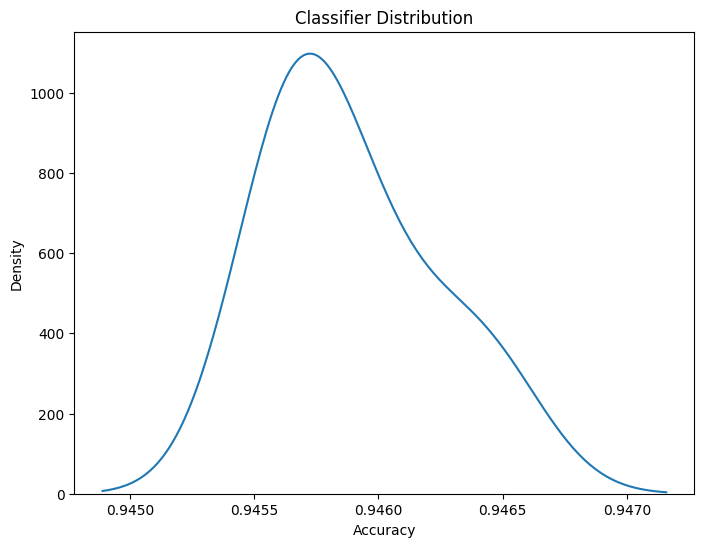

In [ ]:
plt.figure(figsize=(8,6)) #Define o tamanho da imagem
sns.kdeplot(best_param_scores_svm) #Cria gráfico de densidade com as acurácias do melhor índice
plt.title('Classifier Distribution') #Define o título do gráfico
plt.xlabel('Accuracy') #Define o título do eixo x para Accuracy
plt.show() #Mostra o gráfico

In [ ]:
results_svm.to_csv('Results_gridsearch/results_grid_svm.csv') #Exporta o dataframe com o resultado em arquivo .csv

# KNN

In [ ]:
grid_knn_param = {'n_neighbors': [3,7,9]} #Parâmetros de teste do GridSearchCV para o modelo KNN

In [ ]:
grid_knn = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=grid_knn_param, cv=kf,
                       scoring = 'accuracy', verbose=2) #Inicializa o GridSearchCV com o modelo KNN, Kfold e parâmetros de teste

In [ ]:
grid_knn.fit(X_norm_1.astype(np.float32), y_le_1.astype(np.int32)) #Realiza o fit com os dados classficadores normalizados transformado em flaot32 e de target, transformado em int32 

Fitting 5 folds for each of 3 candidates, totalling 15 fits
[CV] END ......................................n_neighbors=3; total time=  11.1s
[CV] END ......................................n_neighbors=3; total time=  10.9s
[CV] END ......................................n_neighbors=3; total time=  10.9s
[CV] END ......................................n_neighbors=3; total time=  10.9s
[CV] END ......................................n_neighbors=3; total time=  11.0s
[CV] END ......................................n_neighbors=7; total time=  11.0s
[CV] END ......................................n_neighbors=7; total time=  11.0s
[CV] END ......................................n_neighbors=7; total time=  11.1s
[CV] END ......................................n_neighbors=7; total time=  11.1s
[CV] END ......................................n_neighbors=7; total time=  11.1s
[CV] END ......................................n_neighbors=9; total time=  11.1s
[CV] END ......................................n_

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [3, 7, 9]}, scoring='accuracy',
             verbose=2)

In [ ]:
grid_knn.best_score_ #Checa os melhores parâmetros

np.float64(0.9353604166666667)

In [ ]:
grid_knn.best_params_ #Checa a melhor acurácia

{'n_neighbors': 9}

In [ ]:
results_knn = pd.DataFrame(grid_knn.cv_results_) #Salva os resultados em um dataframe
test_fold_knn = [results_knn[f'split{i}_test_score'] for i in range(kf.n_splits)] #Separa os dados de acurácia do dataframe

In [ ]:
results_knn #Mostra os resultados do GridSearchCV

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.083768,0.002098,10.862109,0.092221,3,{'n_neighbors': 3},0.929550,0.929212,0.929673,0.929302,0.929833,0.929514,0.000230,3
1,0.081475,0.003936,10.988981,0.031934,7,{'n_neighbors': 7},0.934623,0.934565,0.935238,0.934902,0.934963,0.934858,0.000244,2
2,0.081452,0.004756,11.118772,0.032157,9,{'n_neighbors': 9},0.935056,0.935131,0.935752,0.935538,0.935325,0.935360,0.000257,1


In [ ]:
best_index_knn = grid_knn.best_index_ #Armazena o melhor índice
best_param_scores = [results_knn.loc[best_index_knn, f'split{i}_test_score'] for i in range(kf.n_splits)] #Armazena as acurácias do melhor índice

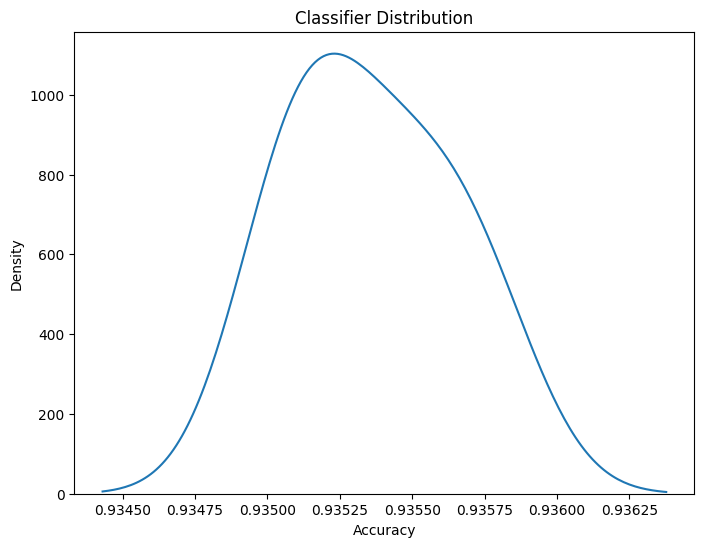

In [ ]:
plt.figure(figsize=(8,6)) #Define o tamanho da imagem
sns.kdeplot(best_param_scores) #Cria gráfico de densidade com as acurácias do melhor índice
plt.title('Classifier Distribution') #Define o título do gráfico
plt.xlabel('Accuracy') #Define o título do eixo x para Accuracy
plt.show() #Mostra o gráfico

In [ ]:
results_knn.to_csv('Results_gridsearch/results_grid_knn.csv') #Exporta o dataframe com o resultado em arquivo .csv

# Random Forest

In [ ]:
grid_param_rf = {'n_estimators': [50,150,200],
              'max_depth': [5,10,15],
              'criterion': ['gini', 'entropy', 'log_loss']} #Parâmetros de teste do GridSearchCV para o modelo RF

In [ ]:
grid_rf = GridSearchCV(estimator=RandomForestClassifier(), param_grid=grid_param_rf, cv=kf,
                       scoring = 'accuracy', verbose=2) #Inicializa o GridSearchCV com o modelo RF, Kfold e parâmetros de teste

In [ ]:
grid_rf.fit(X_norm_1.astype(np.float32), y_le_1.astype(np.int32)) #Realiza o fit com os dados classficadores normalizados transformado em flaot32 e de target, transformado em int32 

Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV] END .......criterion=gini, max_depth=5, n_estimators=50; total time=   6.7s
[CV] END .......criterion=gini, max_depth=5, n_estimators=50; total time=   1.7s
[CV] END .......criterion=gini, max_depth=5, n_estimators=50; total time=   1.8s
[CV] END .......criterion=gini, max_depth=5, n_estimators=50; total time=   1.6s
[CV] END .......criterion=gini, max_depth=5, n_estimators=50; total time=   1.8s
[CV] END ......criterion=gini, max_depth=5, n_estimators=150; total time=   5.1s
[CV] END ......criterion=gini, max_depth=5, n_estimators=150; total time=   5.1s
[CV] END ......criterion=gini, max_depth=5, n_estimators=150; total time=   5.3s
[CV] END ......criterion=gini, max_depth=5, n_estimators=150; total time=   5.0s
[CV] END ......criterion=gini, max_depth=5, n_estimators=150; total time=   5.0s
[CV] END ......criterion=gini, max_depth=5, n_estimators=200; total time=   6.8s
[CV] END ......criterion=gini, max_depth=5, n_e

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RandomForestClassifier(),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [5, 10, 15],
                         'n_estimators': [50, 150, 200]},
             scoring='accuracy', verbose=2)

In [ ]:
grid_rf.best_params_ #Checa os melhores parâmetros

{'criterion': 'gini', 'max_depth': 15, 'n_estimators': 150}

In [ ]:
grid_rf.best_score_ #Checa a melhor acurácia

np.float64(0.90946125)

In [ ]:
results_rf = pd.DataFrame(grid_rf.cv_results_) #Salva os resultados em um dataframe
test_fold_rf = [results_rf[f'split{i}_test_score'] for i in range(kf.n_splits)] #Separa os dados de acurácia do dataframe

In [ ]:
results_rf #Mostra os resultados do GridSearchCV

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,2.396996,1.355252,0.330528,0.629382,gini,5,50,"{'criterion': 'gini', 'max_depth': 5, 'n_estim...",0.855581,0.859590,0.858525,0.851710,0.856531,0.856387,0.002734,19
1,5.081921,0.105818,0.018965,0.000469,gini,5,150,"{'criterion': 'gini', 'max_depth': 5, 'n_estim...",0.848567,0.852348,0.863092,0.860321,0.853383,0.855542,0.005354,22
2,6.860557,0.060626,0.020530,0.000609,gini,5,200,"{'criterion': 'gini', 'max_depth': 5, 'n_estim...",0.849150,0.848821,0.861783,0.854779,0.857121,0.854331,0.004914,25
3,2.580837,0.040950,0.031613,0.002551,gini,10,50,"{'criterion': 'gini', 'max_depth': 10, 'n_esti...",0.897427,0.897813,0.897146,0.897321,0.897242,0.897390,0.000231,16
4,7.688750,0.062593,0.073470,0.006703,gini,10,150,"{'criterion': 'gini', 'max_depth': 10, 'n_esti...",0.898406,0.898450,0.897513,0.898798,0.897988,0.898231,0.000442,10
5,10.242354,0.147507,0.093406,0.006841,gini,10,200,"{'criterion': 'gini', 'max_depth': 10, 'n_esti...",0.898062,0.898302,0.897544,0.898835,0.898225,0.898194,0.000416,13
6,3.427035,0.049357,0.234541,0.020056,gini,15,50,"{'criterion': 'gini', 'max_depth': 15, 'n_esti...",0.908519,0.908892,0.909742,0.909042,0.909417,0.909122,0.000423,7
7,10.251894,0.044004,0.732449,0.006513,gini,15,150,"{'criterion': 'gini', 'max_depth': 15, 'n_esti...",0.909017,0.909223,0.909810,0.909590,0.909667,0.909461,0.000295,1
8,13.604904,0.098383,0.997157,0.012533,gini,15,200,"{'criterion': 'gini', 'max_depth': 15, 'n_esti...",0.908898,0.909117,0.909715,0.909575,0.909544,0.909370,0.000309,4
9,1.733219,0.060735,0.021673,0.012383,entropy,5,50,"{'criterion': 'entropy', 'max_depth': 5, 'n_es...",0.855581,0.859590,0.858525,0.851710,0.856531,0.856387,0.002734,19


In [ ]:
best_index_rf = grid_rf.best_index_ #Armazena o melhor índice
best_param_scores_rf = [results_rf.loc[best_index_rf, f'split{i}_test_score'] for i in range(kf.n_splits)] #Armazena as acurácias do melhor índice

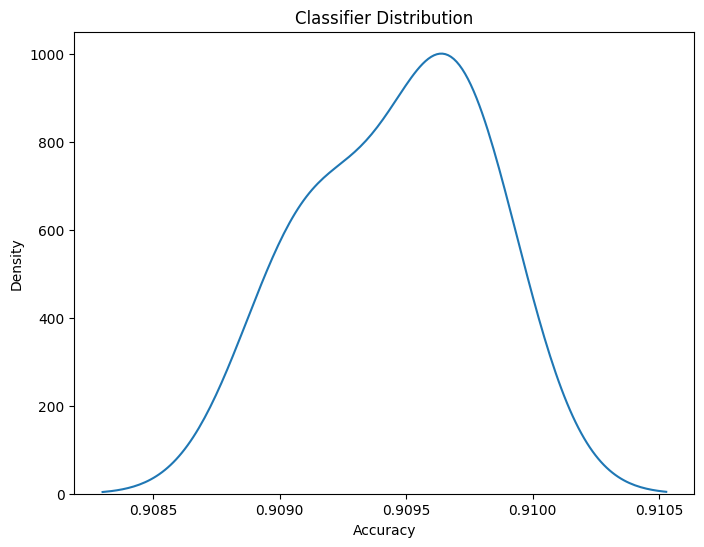

In [ ]:
plt.figure(figsize=(8,6)) #Define o tamanho da imagem
sns.kdeplot(best_param_scores_rf) #Cria gráfico de densidade com as acurácias do melhor índice
plt.title('Classifier Distribution') #Define o título do gráfico
plt.xlabel('Accuracy') #Define o título do eixo x para Accuracy
plt.show() #Mostra o gráfico

In [ ]:
results_rf.to_csv('Results_gridsearch/results_grid_rf.csv') #Exporta o dataframe com o resultado em arquivo .csv

# XGBoost

In [ ]:
param_grid_xgboost = {
    'n_estimators': [50, 150, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.05, 0.1],
} #Parâmetros de teste do GridSearchCV para o modelo XGBoost

In [ ]:
grid_xgboost = GridSearchCV(estimator= XGBClassifier(device='cuda'), param_grid=param_grid_xgboost, cv=kf,
                       scoring = 'accuracy', verbose=2) #Inicializa o GridSearchCV com o modelo XGBoost, Kfold e parâmetros de teste

In [ ]:
grid_xgboost.fit(X_norm_1.astype(np.float32), y_le_1.astype(np.int32)) #Realiza o fit com os dados classficadores normalizados transformado em flaot32 e de target, transformado em int32 

Fitting 5 folds for each of 18 candidates, totalling 90 fits


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:774: UserWarning: [19:51:53] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[CV] END ...learning_rate=0.01, max_depth=3, n_estimators=50; total time=   1.2s
[CV] END ...learning_rate=0.01, max_depth=3, n_estimators=50; total time=   1.0s
[CV] END ...learning_rate=0.01, max_depth=3, n_estimators=50; total time=   1.0s
[CV] END ...learning_rate=0.01, max_depth=3, n_estimators=50; total time=   0.9s
[CV] END ...learning_rate=0.01, max_depth=3, n_estimators=50; total time=   0.9s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=150; total time=   1.2s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=150; total time=   1.2s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=150; total time=   1.2s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=150; total time=   1.2s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=150; total time=   1.2s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=200; total time=   1.3s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=200; total time=   1.3s
[CV] END ..learning_rate=0.0

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device='cuda',
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     i...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 5], 'n_estimators': [50, 150, 200]},
             scoring='accuracy', verbose=2)

In [ ]:
grid_xgboost.best_params_ #Checa os melhores parâmetros

{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}

In [ ]:
grid_xgboost.best_score_ #Checa a melhor acurácia

np.float64(0.9420491666666667)

In [ ]:
results_xgboost = pd.DataFrame(grid_xgboost.cv_results_) #Salva os resultados em um dataframe
test_fold_xgboost = [results_xgboost[f'split{i}_test_score'] for i in range(kf.n_splits)] #Separa os dados de acurácia do dataframe

In [ ]:
results_xgboost #Mostra os resultados do GridSearchCV

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_max_depth,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.971556,0.102668,0.037925,0.001911,0.01,3,50,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est...",0.834221,0.834973,0.833583,0.834777,0.834783,0.834468,0.000509,18
1,1.143483,0.032095,0.039634,0.000280,0.01,3,150,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est...",0.867056,0.867577,0.866663,0.866854,0.866679,0.866966,0.000337,17
2,1.230297,0.027874,0.040363,0.000775,0.01,3,200,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est...",0.879185,0.881008,0.878873,0.879398,0.879852,0.879663,0.000744,15
3,1.101365,0.130509,0.045111,0.014669,0.01,5,50,"{'learning_rate': 0.01, 'max_depth': 5, 'n_est...",0.867779,0.869535,0.867463,0.867308,0.868690,0.868155,0.000840,16
4,1.292296,0.067851,0.040425,0.000127,0.01,5,150,"{'learning_rate': 0.01, 'max_depth': 5, 'n_est...",0.900179,0.900748,0.899127,0.900112,0.899517,0.899937,0.000562,13
5,1.402645,0.021952,0.041550,0.000621,0.01,5,200,"{'learning_rate': 0.01, 'max_depth': 5, 'n_est...",0.907294,0.908050,0.907500,0.908033,0.907133,0.907602,0.000377,12
6,0.949545,0.054245,0.037223,0.000290,0.05,3,50,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",0.886408,0.887371,0.886088,0.886075,0.888794,0.886947,0.001037,14
7,1.137627,0.013396,0.039020,0.000314,0.05,3,150,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",0.917235,0.917848,0.917556,0.918027,0.917365,0.917606,0.000295,9
8,1.225233,0.022534,0.039945,0.000308,0.05,3,200,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",0.922352,0.922133,0.922331,0.923281,0.922635,0.922547,0.000401,8
9,0.992995,0.004307,0.037835,0.000133,0.05,5,50,"{'learning_rate': 0.05, 'max_depth': 5, 'n_est...",0.912202,0.912577,0.912850,0.912885,0.912400,0.912583,0.000261,10


In [ ]:
best_index_xgboost = grid_xgboost.best_index_ #Armazena o melhor índice
best_param_scores_xgboost = [results_xgboost.loc[best_index_xgboost, f'split{i}_test_score'] for i in range(kf.n_splits)] #Armazena as acurácias do melhor índice

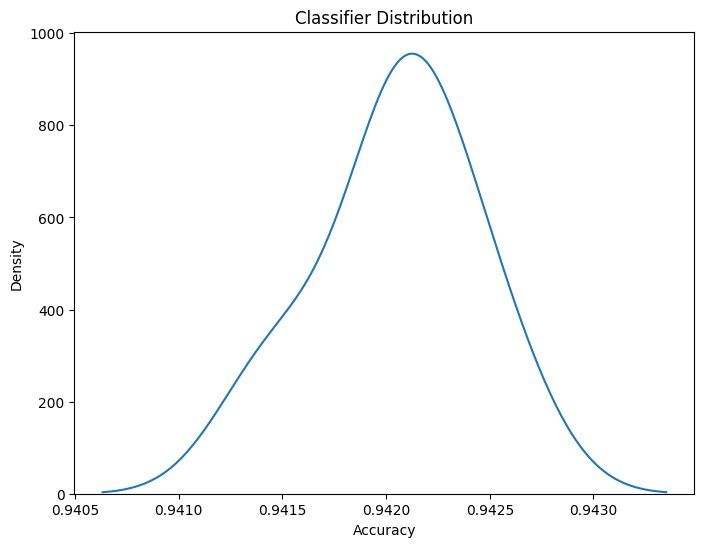

In [ ]:
plt.figure(figsize=(8,6)) #Define o tamanho da imagem
sns.kdeplot(best_param_scores_xgboost) #Cria gráfico de densidade com as acurácias do melhor índice
plt.title('Classifier Distribution') #Define o título do gráfico
plt.xlabel('Accuracy') #Define o título do eixo x para Accuracy
plt.show() #Mostra o gráfico

In [ ]:
results_xgboost.to_csv('Results_gridsearch/results_grid_xgboost.csv') #Exporta o dataframe com o resultado em arquivo .csv

# Rede Neural

In [ ]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu" #Armazena o tipo de device sendo utilizado, sendo cpu ou cuda, utilizando GPU
print(f"Using {device} device")

Using cuda device


In [ ]:
#Rede Neural

class neural_network_2(nn.Module):
  def __init__(self, in_features):
    super().__init__()
    self.flatten = nn.Flatten()
    self.linear_relu_stack = nn.Sequential(
        nn.Linear(in_features,int(in_features*2)), #Cria camada de entrada
        nn.ReLU(), #Função de ativação ReLU
        nn.Linear(int(in_features*2),8), #Segunda camada
        nn.ReLU(), #Função de ativação ReLU
        nn.Linear(8,4), #Terceira camada
        nn.ReLU(), #Função de ativação ReLU
        nn.Linear(4,1), #Camada de saída
        nn.Sigmoid()) # Função sigmoíde

  def forward(self, x):
    x = self.flatten(x)
    logits = self.linear_relu_stack(x)
    return logits.squeeze(-1)

In [ ]:
net_2 = NeuralNetClassifier(neural_network_2,
                          criterion=nn.BCELoss(),
                            max_epochs=2,
                         train_split=False, verbose=0) #Cria a rede neural com skorch

In [ ]:
param_grid_net_2 = {
    'lr': [0.01,0.1],
} #Parâmetros de teste do GridSearchCV para o modelo de Rede Neural

In [ ]:
net_2.set_params(module__in_features = np.prod(X_norm_1.shape[1:])) #Define o número de features de entrada, como o número de colunas dos dados

In [ ]:
grid_net_2 = GridSearchCV(estimator=net_2, param_grid=param_grid_net_2, cv=kf,
                       scoring = 'accuracy', verbose=2) #Inicializa o GridSearchCV com o modelo de Rede Neural, Kfold e parâmetros de teste

In [ ]:
grid_net_2.fit(X_norm_1.astype(np.float32), y_le_1.astype(np.float32)) #Realiza o fit com os dados classficadores normalizados transformado em flaot32 
                                                                       #e de target, transformado em float32

In [ ]:
grid_net_2.best_score_ #Checa a melhor acurácia

In [ ]:
grid_net_2.best_params_ #Checa os melhores parâmetros

In [ ]:
results_net_2 = pd.DataFrame(grid_net_2.cv_results_) #Salva os resultados em um dataframe
test_fold_net_2 = [results_net_2[f'split{i}_test_score'] for i in range(kf.n_splits)] #Separa os dados de acurácia do dataframe

In [ ]:
results_net_2 #Mostra os resultados do GridSearchCV

In [ ]:
best_index_net_2 = grid_net_2.best_index_ #Armazena o melhor índice
best_param_scores_net_2 = [results_net_2.loc[best_index_net_2, f'split{i}_test_score'] for i in range(kf.n_splits)] #Armazena as acurácias do melhor índice

In [ ]:
plt.figure(figsize=(8,6)) #Define o tamanho da imagem
sns.kdeplot(best_param_scores_net_2) #Cria gráfico de densidade com as acurácias do melhor índice
plt.title('Classifier Distribution') #Define o título do gráfico
plt.xlabel('Accuracy') #Define o título do eixo x para Accuracy
plt.show() #Mostra o gráfico

In [ ]:
results_net_2.to_csv('Results_gridsearch/results_grid_neural_network_2.csv') #Exporta o dataframe com o resultado em arquivo .csv

# Gaussian Naive-Bayes

Como o Gaussian Naive-Bayes não possui parâmetros para alterar, o GridSearchCV não pode ser realizado com o modelo